# Automated segmentation of lumbar spine structures (Intervertebral Disc (IVD), Posterior Element (PE), Thecal Sac (TS), and the Area between Anterior and Posterior (AAP) vertebrae)

## 0. Boilerplate

In [ ]:
from torch.utils.data import Dataset
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import monai
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from monai.metrics import DiceMetric
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb
import gc

device = 'cuda' if torch.cuda.is_available() else 'cpu'

2025-04-25 19:18:30.252359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745608710.274576     141 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745608710.281402     141 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.


## 1. Dataloading

### Custom PyTorch Dataset for loading data

In [4]:
class LSS_Dataset(Dataset): # Custom PyTorch Dataset for loading lumbar ct image and corresponding masks

    def __init__(self, data_dir, images_files, masks_files, transform):
        self.data_dir = data_dir # Root directory where data is stored
        self.images_files = images_files # List of image filenames
        self.labels_files = masks_files # List of corresponding mask filenames
        self.transform = transform # Albumentations transform to apply on the image-mask pair

    def load_img(self, img_path):
        # Load a grayscale ct image using OpenCV
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        return img
    
    def preprocess_mask(self, mask):
        # Map pixel values in the mask to class indices
        value_map = {0: 1, 100: 2, 200: 3, 250: 4, 255: 0}
        mask_out = np.zeros_like(mask, dtype=np.uint8)
        for pixel_val, class_idx in value_map.items():
            mask_out[mask == pixel_val] = class_idx
        return mask_out

    
    def load_mask(self, msk_path):
        # Load a mask and preprocess it to map pixel values to class labels
        msk = cv2.imread(msk_path, cv2.IMREAD_UNCHANGED)
        mask_out = self.preprocess_mask(msk)
        return mask_out

    def __getitem__(self, idx):
        # Sanity check: ensure that image and mask filenames match
        if self.images_files[idx][3:] != self.labels_files[idx][3:]:
            print(self.images_files[idx], self.labels_files[idx])
            raise AssertionError("Mask don't match image")

        img_path = os.path.join(self.data_dir,"T1_Output", self.images_files[idx])
        msk_path = os.path.join(self.data_dir,"Label_Images", self.labels_files[idx])

        # Load image and mask
        img = self.load_img(img_path)
        msk = self.load_mask(msk_path)

        # Apply augmentations and preprocessing
        augmented = self.transform(image = img, mask = msk)

        sample = {
            "image": augmented["image"].float(), # conver to float to match the model weights type
            "mask" : F.one_hot(augmented["mask"].long(), 5).permute(2, 0, 1).float()
            # One-hot encode the mask and reshape to (C, H, W) where c equal the number of classes
        }

        return sample
        
    def __len__(self):
 
        return len(self.images_files)


### loading and splitting the data into train, val, and test splits

In [5]:
data_dir = "/kaggle/input/dataset/data"

# reading the ct scans simages
ct_images_files = sorted(os.listdir(os.path.join(data_dir,"T1_Output")))

# reading the masks
masks_files = sorted(os.listdir(os.path.join(data_dir,"Label_Images")))

# determin the patient of each image, to split them based on patient
patients = np.unique([file[3:7] for file in ct_images_files])

# data split into 60% train, 20% val, and 20% test
# Step 1: Split into train (60%) and temp (40%)
train_patients, temp_patients = train_test_split(patients, test_size=0.4, random_state=42)
# Step 2: Split temp into validation (20%) and test (20%)
val_patients, test_patients = train_test_split(temp_patients, test_size=0.5, random_state=42)

# function to filter files by patient group
def filter_by_patients(file_list, patient_list):
    return [f for f in file_list if f[3:7] in patient_list]

# split CT images and masks according to patient group
train_images = filter_by_patients(ct_images_files, train_patients)
val_images = filter_by_patients(ct_images_files, val_patients)
test_images = filter_by_patients(ct_images_files, test_patients)

train_masks = filter_by_patients(masks_files, train_patients)
val_masks = filter_by_patients(masks_files, val_patients)
test_masks = filter_by_patients(masks_files, test_patients)



## 2. Preprocessing and augmentation

In [6]:
# Define training augmentations and normalization
train_transform = A.Compose([
                            A.Resize(height=256, width=256, p=1, 
                             interpolation=cv2.INTER_LINEAR, 
                             mask_interpolation=cv2.INTER_NEAREST), # resize all images to 256 * 256
                            A.Affine( # Apply slight geometric transformations
                            rotate=(-10, 10),
                            scale=(0.95, 1.05),
                            translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
                            p=0.5 
                            ), 
                            A.Normalize(normalization = "min_max", p=1.0), # Normalize to [0, 1]
                            ToTensorV2() # Convert to PyTorch tensor
                            ])

# Define validation transforms (no augmentation, just resize + normalize)
val_transform = A.Compose([
                            A.Resize(height=256, width=256, p=1, 
                             interpolation=cv2.INTER_LINEAR, 
                             mask_interpolation=cv2.INTER_NEAREST),
                            A.Normalize(normalization = "min_max", p=1.0),
                            ToTensorV2()
                            ])

# Create dataset instances with transforms
train_dataset = LSS_Dataset(data_dir, train_images, train_masks, train_transform)
val_dataset = LSS_Dataset(data_dir, val_images, val_masks, val_transform)
test_dataset = LSS_Dataset(data_dir, test_images, test_masks, val_transform)

# Initialize DataLoader for training, validation, and test sets

train_loader = DataLoader(train_dataset, batch_size= 16)
val_loader = DataLoader(val_dataset, batch_size= 16)
test_loader = DataLoader(test_dataset, batch_size= 16)



# 3. Defining Model

### Squeeze adn Excitation (attention mechanism)

In [7]:
from enum import Enum

import torch
import torch.nn as nn
import torch.nn.functional as F

# Here Squeez and exitation attention mechanism is applied to use it with the Unet model

# Code for Squeeze-and-Excitation (SE) blocks adapted from:
# ai-med/squeeze_and_excitation repository (https://github.com/ai-med/squeeze_and_excitation)

class ChannelSELayer(nn.Module): # Squeeze-and-Excitation block (Channel-wise attention)
    """
    Re-implementation of Squeeze-and-Excitation (SE) block described in:
        *Hu et al., Squeeze-and-Excitation Networks, arXiv:1709.01507*

    """

    def __init__(self, num_channels, reduction_ratio=2):
        """

        :param num_channels: No of input channels
        :param reduction_ratio: By how much should the num_channels should be reduced
        """
        super(ChannelSELayer, self).__init__()
        num_channels_reduced = num_channels // reduction_ratio
        self.reduction_ratio = reduction_ratio
        self.fc1 = nn.Linear(num_channels, num_channels_reduced, bias=True)
        self.fc2 = nn.Linear(num_channels_reduced, num_channels, bias=True)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_tensor):
        """

        :param input_tensor: X, shape = (batch_size, num_channels, H, W)
        :return: output tensor
        """
        batch_size, num_channels, H, W = input_tensor.size()
        # Average along each channel
        squeeze_tensor = input_tensor.view(batch_size, num_channels, -1).mean(dim=2)

        # channel excitation
        fc_out_1 = self.relu(self.fc1(squeeze_tensor))
        fc_out_2 = self.sigmoid(self.fc2(fc_out_1))

        # Re-weight input tensor channels
        a, b = squeeze_tensor.size()
        output_tensor = torch.mul(input_tensor, fc_out_2.view(a, b, 1, 1))
        return output_tensor


class SpatialSELayer(nn.Module):
    """
    Spatial Squeeze-and-Excitation (spatial attention)
    Ref: Roy et al., MICCAI 2018
    """

    def __init__(self, num_channels):
        """

        :param num_channels: No of input channels
        """
        super(SpatialSELayer, self).__init__()
        self.conv = nn.Conv2d(num_channels, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_tensor, weights=None):
        """

        :param weights: weights for few shot learning
        :param input_tensor: X, shape = (batch_size, num_channels, H, W)
        :return: output_tensor
        """
        # spatial squeeze
        batch_size, channel, a, b = input_tensor.size()

        if weights is not None:
            weights = torch.mean(weights, dim=0)
            weights = weights.view(1, channel, 1, 1)
            out = F.conv2d(input_tensor, weights)
        else:
            out = self.conv(input_tensor)
        squeeze_tensor = self.sigmoid(out)

        # spatial excitation
        # print(input_tensor.size(), squeeze_tensor.size())
        squeeze_tensor = squeeze_tensor.view(batch_size, 1, a, b)
        output_tensor = torch.mul(input_tensor, squeeze_tensor)
        #output_tensor = torch.mul(input_tensor, squeeze_tensor)
        return output_tensor


class ChannelSpatialSELayer(nn.Module): # Combined Channel + Spatial Squeeze-and-Excitation
    """
    Combined Channel + Spatial Squeeze-and-Excitation
    Ref: Roy et al., MICCAI 2018
    """

    def __init__(self, num_channels, reduction_ratio=2):
        """

        :param num_channels: No of input channels
        :param reduction_ratio: By how much should the num_channels should be reduced
        """
        super(ChannelSpatialSELayer, self).__init__()
        self.cSE = ChannelSELayer(num_channels, reduction_ratio)
        self.sSE = SpatialSELayer(num_channels)

    def forward(self, input_tensor):
        """

        :param input_tensor: X, shape = (batch_size, num_channels, H, W)
        :return: output_tensor
        """
        # Take element-wise max of channel and spatial attention outputs
        output_tensor = torch.max(self.cSE(input_tensor), self.sSE(input_tensor))
        return output_tensor


### Unet model network

In [8]:
# This code is adapted from https://github.com/milesial/Pytorch-UNet/tree/master
# Modifications were made to add optional SE blocks, dropout, and custom configurations for the UNet architecture.
class DoubleConv(nn.Module):
    """(Conv => BN => LeakyReLU => Dropout) * 2 with optional SE block"""

    def __init__(self, in_channels, out_channels, drop_out , SE, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels

        # Two convolutional blocks
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(drop_out),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(drop_out)
        )
        # Optional SE layer if 1 apply channel wise if 2 apply channel-spatial attention
        if SE == 1:
            self.se_layer = ChannelSELayer(out_channels)
        elif SE == 2:
            self.se_layer = ChannelSpatialSELayer(out_channels)
        else:
            self.se_layer = None

    def forward(self, x):

        x = self.double_conv(x)
        if self.se_layer is not None:
            x = self.se_layer(x)
        return x


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels, drop_out, SE):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels, drop_out, SE)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, drop_out, SE):
        super().__init__()

        
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels, drop_out, SE)
        

    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)
    
class UNet(nn.Module):
    """U-Net with optional SE blocks and dropout"""
    def __init__(self, n_channels, n_classes, drop_out, SE,  channels = [32, 64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Encoder path
        self.inc = (DoubleConv(n_channels, channels[0], drop_out, SE)) # 256
        self.down1 = (Down(channels[0], channels[1], drop_out, SE)) # 128
        self.down2 = (Down(channels[1], channels[2], drop_out, SE)) # 64
        self.down3 = (Down(channels[2], channels[3], drop_out, SE)) # 32
        self.down4 = (Down(channels[3], channels[4], drop_out, SE)) # 16
        # Decoder path
        self.up1 = (Up(channels[4], channels[3], drop_out, SE))
        self.up2 = (Up(channels[3], channels[2], drop_out, SE))
        self.up3 = (Up(channels[2], channels[1], drop_out, SE))
        self.up4 = (Up(channels[1], channels[0], drop_out, SE))
        # Final output
        self.outc = (OutConv(channels[0], n_classes))

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        # Output
        logits = self.outc(x)
        return logits

    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        self.down4 = torch.utils.checkpoint(self.down4)
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.up4 = torch.utils.checkpoint(self.up4)
        self.outc = torch.utils.checkpoint(self.outc)


## 4. Defining hyperparameters

In [9]:
sweep_config = {
    'method': 'random',  # random hyperparameters search
    'metric': {
        'name': 'avg_val_dice',  # Metric to optimize
        'goal': 'maximize'   # Objective is to maximize validation Dice score
    },
    'parameters': {
        'learning_rate': {
            
            'distribution': 'log_uniform_values',  # Log scale for better LR exploration
            'min': 1e-4,    # Minimum LR
            'max': 1e-3     # Maximum LR
        },
        
        'optimizer': {
            'values': ["Adam", "AdamW"]  # Try both optimizers
        },

        'scheduler_factor': {
            'distribution': 'uniform', # Linear distribution for LR scheduler factor
            'min': 0.1,    # Minimum value for the range
            'max': 0.3     # Maximum value for the range
        },
        'scheduler_patience': {
            'values': [5, 6, 7, 8, 9, 10], # Patience before reducing LR
        },


        'weighted_loss': {
            
            'values': [False, True], # Try both with and without class weighting
        },
        'loss': {
            
            'values': [ 'DiceLoss', 'DiceFocalLoss'], # Explore both Dice and Dice+Focal loss
        },

        'dropout': {
            
            'values': [0,0.1,0.2,0.3,0.4,0.5], # Regularization via dropout
        },
        
        'max_norm': {
            
            'values': [1, 2, 3, 4, 5], # Gradient clipping to prevent exploding gradients
        },


        "se": {
            
            'values': [0, 1, 2], # Squeeze-and-Excitation: 0 (none), 1 (channel), 2 (channel + spatial)
        },
        "channels": {
            
            'values': [[32, 64, 128, 256, 512],  # Smaller U-Net
                       [ 64, 128, 256, 512, 1024]], # Larger U-Net
        },
        
   
    }
}


## 5. Training and validation 

### Designing the training and val engine

In [10]:
def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer,
               scaler: torch.amp.GradScaler,
               max_norm: int,
               device: torch.device
               ):
    """
    Trains a PyTorch model for one epoch.

    Args:
        model: The neural network model to train.
        dataloader: DataLoader providing training data.
        loss_fn: Loss function to compute the error.
        optimizer: Optimizer to update model weights.
        scaler: Gradient scaler for mixed precision training.
        max_norm: Max norm for gradient clipping.
        device: Device on which to perform computations.

    Returns:
        class_dice_scores: Dice scores for each class.
        class_dice_scores_mean: Mean Dice score.
        train_loss: Average loss for the epoch.
    """

    train_loss = 0
    # Dice metrics for per-class and average calculation
    train_dice_metric = DiceMetric(include_background=False, reduction  = "mean_batch", return_with_label=True)
    train_dice_metric_mean = DiceMetric(include_background=False, reduction  = "mean")
    
    model.train() # Set model to training mode
    for batch, sample in enumerate(dataloader):
        
        X  = sample["image"]
        y = sample["mask"]

        X, y = X.to(device), y.to(device) # move data to the same device of the model

        optimizer.zero_grad() # Reset gradients
        
        # Mixed precision forward pass for optimization
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=True):
            
            y_pred = F.softmax(model(X), dim=1) # Forward pass + softmax

            loss = loss_fn(y_pred, y) # Compute loss

        # accumulate loss across batches
        train_loss += loss.item() #

        # Loss backward
        scaler.scale(loss).backward()

        # Unscale gradients
        scaler.unscale_(optimizer)

        # Clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)

        # Optimizer step
        scaler.step(optimizer)

        # Updates the scale for next iteration.
        scaler.update()
        
        # Convert predictions to one-hot encoding for Dice
        y_pred = y_pred.argmax(dim=1)
        y_pred = F.one_hot(y_pred, 5).permute(0, 3, 1, 2).float() 
        
        # Update Dice Metric
        train_dice_metric(y_pred, y)
        train_dice_metric_mean(y_pred, y)

    # Compute and log Dice score after each epoch for each class and mean
    class_dice_scores = train_dice_metric.aggregate()  # Get Dice score for each class
    train_dice_metric.reset()  # Reset the metric for the next epoch

    class_dice_scores_mean = train_dice_metric_mean.aggregate().item()  # Get Dice score for mean
    train_dice_metric_mean.reset()  # Reset the metric for the next epoch
    
    train_loss = train_loss/len(train_loader) # Average training loss

    # Clean up memory

    try:
        del X, y, y_pred, loss
    except:
        pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    return class_dice_scores, class_dice_scores_mean, train_loss
    

def val_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              device: torch.device) -> tuple[float, float]:
    """
    Validates a PyTorch model for one epoch.

    Args:
        model: The neural network model to validate.
        dataloader: DataLoader providing validation data.
        loss_fn: Loss function to compute the error.
        device: Device on which to perform computations.

    Returns:
        class_dice_scores: Dice scores for each class.
        class_dice_scores_mean: Mean Dice score.
        val_loss: Average validation loss for the epoch.
    """
    # Put model in eval mode
    model.eval() 

    # Setup val loss
    val_loss = 0

    # Dice metrics for validation
    val_dice_metric = DiceMetric(include_background=False, reduction  = "mean_batch", return_with_label=True)
    val_dice_metric_mean = DiceMetric(include_background=False, reduction  = "mean")

    # Disable gradient tracking
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, sample in enumerate(dataloader):

            X  = sample["image"]
            y = sample["mask"]

            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            y_pred = F.softmax(model(X), dim=1)

            # 2. Calculate and accumulate loss
            if loss_fn is not None:
                loss = loss_fn(y_pred, y)
        
                val_loss += loss.item()

            # Convert predictions to one-hot encoding for Dice
            y_pred = F.one_hot(y_pred.argmax(dim=1), 5).permute(0, 3, 1, 2).float() 

            # Update Dice metrics
            val_dice_metric(y_pred, y)
            val_dice_metric_mean(y_pred, y)

    # Aggregate Dice scores
    class_dice_scores = val_dice_metric.aggregate()  # Get Dice score for each class
    val_dice_metric.reset()  # Reset the metric for the next epoch

    class_dice_scores_mean = val_dice_metric_mean.aggregate().item()  # Get Dice score for mean
    val_dice_metric_mean.reset()  # Reset the metric for the next epoch
    
    val_loss = val_loss/len(dataloader) # Average validation loss

    # Clean up memory
    try:
        del X, y, y_pred, loss
    except:
        pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    return class_dice_scores, class_dice_scores_mean,val_loss

### Init training opt, schedular, loss, and model

In [ ]:

def train():
    
    # Initialize the wandb run
    wandb.init()
    config = wandb.config
    
    # Set training EPOCHS
    NUM_EPOCHS = 50

    # Create model instance based on config
    model = UNet(1, 5, config.dropout,config.se, channels=config.channels)
    model = model.to(device)

    # Set up optimizer
    optimizer = getattr(torch.optim, config.optimizer)(model.parameters(), config.learning_rate)
    
    # Enable mixed-precision training
    scaler = torch.GradScaler("cuda" ,enabled=True)
    
    # Learning rate scheduler (Reduce LR on Plateau)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=config.scheduler_factor, patience=config.scheduler_patience, threshold=1e-4, min_lr = 1e-6, mode = "min", verbose = True)

    # Set class weights if using weighted loss, the weights were computed by taking the inverse of the each calss count and then normalize them 
    # to one without background
    weight = [0.0396, 0.0966, 0.5225, 0.3395] if config.weighted_loss else None 

    # Initialize loss function from MONAI
    loss_fn = getattr(monai.losses, config.loss)(weight=weight, include_background=  False)

    # start training loop
    for epoch in tqdm(range(NUM_EPOCHS)):
 
        ###########################Train##############################
        train_dice, avg_train_dice, train_loss = train_step(model=model,
                                                dataloader=train_loader,
                                                loss_fn=loss_fn,
                                                optimizer=optimizer,
                                                scaler=scaler,
                                                max_norm=config.max_norm,
                                                device=device)
        ###########################val##############################
        val_dice, avg_val_dice, val_loss = val_step(model=model,
                                            dataloader=val_loader,
                                            loss_fn=loss_fn,
                                            device=device)
        # Update scheduler with validation loss
        scheduler.step(val_loss)
        
        # Log metrics to wandb
        fold_results = {
                "avg_train_dice": avg_train_dice,
                "avg_val_dice": avg_val_dice,
                "train_loss": train_loss,
                "val_loss": val_loss,
            }
        wandb.log(fold_results)

        # Print metrics for current epoch
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Validation Loss: {val_loss:.4f}")
    
        print("\nTrain Dice Scores for each class:")
        for i, (class_name, score) in enumerate(train_dice.items()):
            print(f"Class {class_name} Dice Score: {score:.4f}")
        
        print(f"Average Train Dice Score: {avg_train_dice:.4f}")
    
        print("\nValidation Dice Scores for each class:")
        for i, (class_name, score) in enumerate(val_dice.items()):
            print(f"Class {class_name} Dice Score: {score:.4f}")
        
        print(f"Average Validation Dice Score: {avg_val_dice:.4f}")
        print("-" * 50)


    # Save trained model
    torch.save(model.state_dict(), "model.pth")
    # Log model as wandb artifact
    artifact = wandb.Artifact('model', type='model')
    artifact.add_file("model.pth")
    wandb.log_artifact(artifact)
    
    ###############################################
    
    # Clean up at the end of training
    del model, optimizer, loss_fn, scaler
    gc.collect()
    torch.cuda.empty_cache()
    
    # Finish wandb run
    wandb.finish()


### login to wandb and init the sweep

In [12]:
# Log in to Weights & Biases using the API key
wandb.login(key="xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx")
# Create a sweep with the defined configuration for random search for the best hyperparameters set
sweep_id = wandb.sweep(sweep_config, project="final_proj", entity="aelbada-western-university")
# Launch the W&B agent to run the sweep using the `train` function, running 50 experiments
wandb.agent(sweep_id, function=train, count=25) 

## 6. Inference

### Loading the best model and infer on the test split

In [13]:
best_model = UNet(1, 5, drop_out=0.3, SE=1, channels=[64, 128, 256, 512, 1024])
best_model = best_model.to(device)
# Load the saved model weights
best_model.load_state_dict(torch.load("/kaggle/input/best_model/pytorch/default/1/model.pth", weights_only=True))
# the model in evaluation mode
best_model.eval()
# Using val step engine to evaluate and infer on the test set
test_dice, avg_test_dice, test_loss = val_step(model=best_model,
                                            dataloader=test_loader,
                                            loss_fn=None,
                                            device=device)

print(f"Dice coefficient for each class: {test_dice}", f"Average Dice coefficient : {avg_test_dice}")

Dice coefficient for each class: {'label_1': 0.982, 'label_2': 0.9459, 'label_3': 0.9459, 'label_4': 0.8377} Average Dice coefficient : 0.9278770089149475


## 7. Output

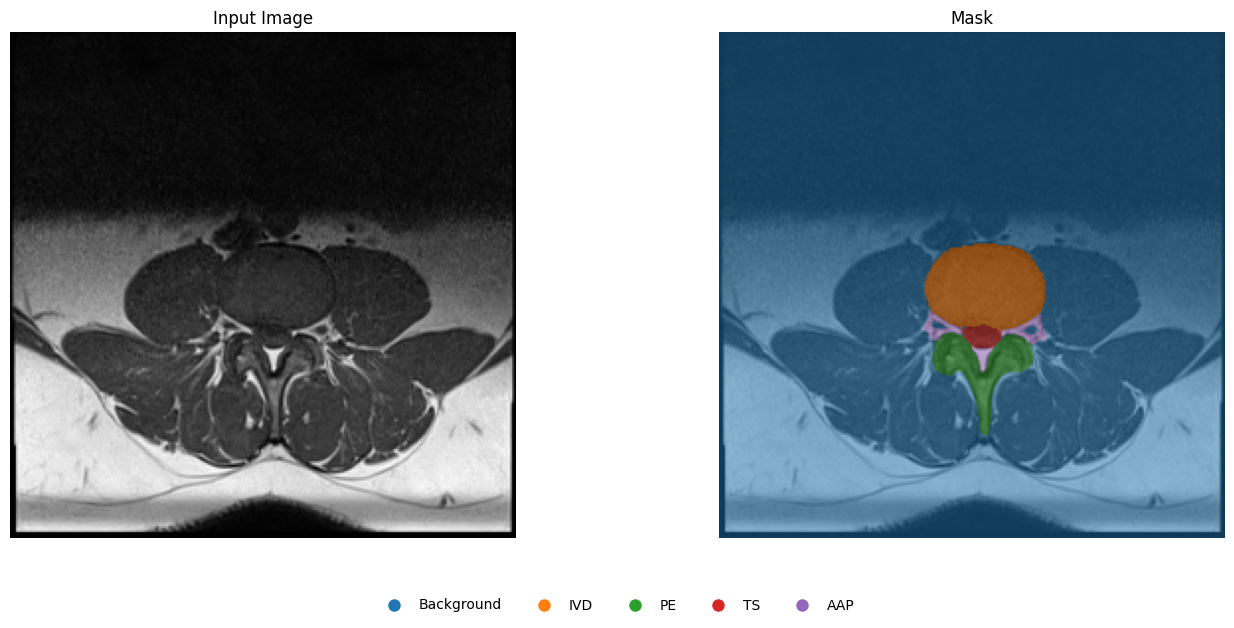

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch

# Get a single sample from the test loader
sample = next(iter(test_loader))

# Extract image and mask from the sample
X = sample["image"]
y_true = sample["mask"]

X = X.to(device)
y_true = y_true.to(device)

# Model prediction
best_model.eval()
with torch.no_grad():
    y_pred = best_model(X)

# Softmax and argmax
y_pred_prob = torch.softmax(y_pred, dim=1)
y_pred_class = torch.argmax(y_pred_prob, dim=1)

# Choose distinct colors from 'tab10'
cmap_tab10 = plt.get_cmap('tab10')
class_colors = [cmap_tab10(i) for i in range(5)]  # Adjust if you have more classes

# Create colormap and norm
cmap = mcolors.ListedColormap(class_colors)
bounds = np.arange(6) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Prepare image and mask
image = X[0].cpu().numpy()
image = image[0]

pred_mask = y_pred_class[0].cpu().numpy().astype(int)
rgba_overlay = cmap(norm(pred_mask))
overlay = rgba_overlay[..., :3]

# Blend
alpha = 0.5
image_gray_rgb = np.stack([image]*3, axis=-1)  # Convert grayscale to RGB
image_with_mask = (1 - alpha) * image_gray_rgb + alpha * overlay

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # Adjusted to 2 subplots

# Plot the grayscale image
axes[0].imshow(image, cmap='gray')
axes[0].set_title("Input Image")
axes[0].axis('off')

# Plot the overlay
axes[1].imshow(image_with_mask)
axes[1].set_title("Mask")
axes[1].axis('off')

# Legend
class_labels = ['Background', 'IVD', 'PE', 'TS', 'AAP']
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=label,
               markerfacecolor=class_colors[i], markersize=10)
    for i, label in enumerate(class_labels)
]

fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05), frameon=False)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()
